# Construction du dataset SFT

Objectif : construire le dataset SFT à partir des cas de triage annotés et des trois sources de questions (MediQAl, FrenchMedMCQA, MedQuAD).

Le dataset réunit deux sortes d'exemples :

- **triage** : un cas de patient, et la réponse attendue en JSON (niveau d'urgence, spécialité, symptômes, signes d'alerte, justification, recommandation) ;
- **QA** : une question médicale, et la réponse attendue en texte libre.

Les splits ne sont pas tirés ici. Ils viennent du découpage par cas du notebook 03, fait une seule fois pour toutes les sources.

Ce notebook exécute et documente les fonctions de `scripts/extraction.py` et de `scripts/examples.py`, pour garder une trace des transformations appliquées.

In [1]:
import sys
import warnings
from collections import Counter

sys.path.append("..")
# tqdm signale qu'ipywidgets manque (barres de progression) : sans effet sur les calculs
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import pandas as pd

from app.prompts import construire_prompt
from scripts.anonymisation import anonymize_french_sources
from scripts.cases import find_leaks, split_cases
from scripts.examples import build_qa_examples, build_triage_examples, sample_qa_examples
from scripts.extraction import (
    TAILLE_QA, build_sft_dataset, clean_sft_dataset, load_annotations, load_frenchmedmcqa, load_mediqa,
    load_medquad, load_ultramedical_preference,
)
from src.visualizer import create_barplot, save_figure

SPLITS = ["train", "validation", "test"]
NIVEAUX = ["maximum", "moderate", "deferred"]

## Nettoyage du QA

### Doublons exacts

Doublons exacts (instruction, reponse), source par source. L'exploration a repéré 48 doublons exacts dans MedQuAD, 1 doublon exact dans FrenchMedMCQA, aucun dans MediQAl.

**MedQuAD : 48 doublons exacts.** 48 lignes partagent exactement le même couple (question, réponse) qu'une autre ligne.

In [2]:
medquad = load_medquad()
print("medquad brut :", len(medquad))

cles = [(r["instruction"], r["reponse"]) for r in medquad]
compteur = Counter(cles)
doublons = {cle: n for cle, n in compteur.items() if n > 1}
print("couples (instruction, reponse) en double :", len(doublons))
print("lignes en trop à retirer :", sum(n - 1 for n in doublons.values()))

medquad brut : 16407
couples (instruction, reponse) en double : 32
lignes en trop à retirer : 48


Trois exemples de doublons, pour voir à quoi ils ressemblent :

In [3]:
for instruction, reponse in list(doublons.keys())[:3]:
    print("instruction :", instruction)
    print("reponse     :", reponse[:150].replace("\n", " "), "...")
    print()

instruction : What is (are) Hypoglycemia ?
reponse     : Hypoglycemia, also called low blood glucose or low blood sugar, occurs when blood glucose drops below normal levels. Glucose, an important source of e ...

instruction : What are the symptoms of Hypoglycemia ?
reponse     : Hypoglycemia causes symptoms such as                  - hunger  - shakiness  - nervousness  - sweating  - dizziness or light-headedness  - sleepiness  ...

instruction : What causes Hypoglycemia ?
reponse     : Diabetes Medications                  Hypoglycemia can occur as a side effect of some diabetes medications, including insulin and oral diabetes medica ...



Comme repéré dans le notebook 01, ce sont des questions génériques qui reviennent (« What is (are) Hypoglycemia ? » posée deux fois avec la même réponse), pas des variantes à garder : ce sont bien des doublons exacts à retirer.

**FrenchMedMCQA : 1 doublon exact.** Une question sur Streptococcus pneumoniae apparaît deux fois dans le split train d'origine, avec le même id.

In [4]:
frenchmedmcqa = load_frenchmedmcqa()
print("frenchmedmcqa brut :", len(frenchmedmcqa))

cles = [(r["instruction"], r["reponse"]) for r in frenchmedmcqa]
compteur = Counter(cles)
doublons = {cle: n for cle, n in compteur.items() if n > 1}
print("couples en double :", len(doublons))

for instruction, reponse in doublons.keys():
    print("instruction :", instruction)
    print("reponse     :", reponse)

frenchmedmcqa brut : 1080
couples en double : 1
instruction : Parmi les caractères suivants, lequel n'est pas retrouvé chez Streptococcus pneumoniae ?
a) Présence d'une capsule
b) Catalase négative
c) Survie en aérobiose et anaérobiose
d) Production d'une toxine de Panton-Valentine
e) Hémolytique sur gélose au sang
reponse     : d) Production d'une toxine de Panton-Valentine


**MediQAl : aucun doublon.** Confirmation sur les questions chargées par `load_mediqa`, cohérente avec le notebook 01.

In [5]:
mediqa = load_mediqa()
print("mediqa brut :", len(mediqa))

cles = [(r["instruction"], r["reponse"]) for r in mediqa]
print("couples uniques :", len(set(cles)))

mediqa brut : 4969
couples uniques : 4969


### Point d'interrogation en trop dans MedQuAD

Certaines questions MedQuAD finissent par « ? ? » : la question avait déjà son point d'interrogation, et un second a été ajouté derrière. `load_medquad` retire celui en trop et note `correction_ponctuation` dans les `transformations` de l'exemple. La clé de cas reste calculée sur la question d'origine, le découpage ne change donc pas.

In [6]:
corrigees = [r for r in medquad if "correction_ponctuation" in r["transformations"]]
print("questions corrigées :", len(corrigees), "sur", len(medquad))
for record in corrigees[:3]:
    print("-", record["instruction"])

questions corrigées : 322 sur 16407
- Who is at risk for Lymphocytic Choriomeningitis (LCM)?
- Who is at risk for Lymphocytic Choriomeningitis (LCM)?
- Who is at risk for Parasites - Cysticercosis?


### Questions négatives de FrenchMedMCQA

Le notebook 01 a compté 454 questions négatives sur 1080 (« laquelle est fausse ? », « sauf », « n'est pas »). Pour ces questions, la bonne proposition est une affirmation fausse. Ce serait un problème si la réponse était donnée seule, sans les propositions : le modèle apprendrait une affirmation fausse.

Ce n'est pas le cas ici. `load_frenchmedmcqa` garde les cinq propositions dans l'instruction et répond par la lettre et son texte. Le modèle apprend à désigner la bonne proposition du QCM, comme dans l'exemple ci dessous. Ces questions sont donc gardées telles quelles.

In [7]:
exemple = next(r for r in frenchmedmcqa if "fausse" in r["instruction"].split("\n")[0])
print("instruction :", exemple["instruction"])
print("reponse     :", exemple["reponse"])

instruction : Parmi les affirmations suivantes, une seule est fausse, indiquer laquelle: les particules alpha
a) Sont formées de noyaux d'hélium
b) Sont peu pénétrantes
c) Toute l'énergie qu'elles transportent est cédée au long d'un parcours de quelques centimètres dans l'air
d) Sont arrêtées par une feuille de papier
e) Sont peu ionisantes
reponse     : e) Sont peu ionisantes


## Découpage par cas

Le split de chaque exemple est lu dans le découpage par cas du notebook 03. Toutes les sources y entrent ensemble, y compris les prompts UltraMedical qui serviront au DPO, pour qu'un même cas ne puisse pas se retrouver dans deux splits.

Les sources sont déjà chargées plus haut. Je les réunis dans le même ordre que `load_split_units`, pour retrouver exactement le découpage du notebook 03.

In [8]:
annotations = load_annotations()
dpo = load_ultramedical_preference()

unites = annotations + mediqa + frenchmedmcqa + medquad + dpo
splits = split_cases(unites)
print("clés de cas :", len(splits))
print({split: n for split, n in Counter(splits.values()).most_common()})

UltraMedical-Preference test: 100%|██████████| 777/777 [00:00<00:00, 2769.70it/s]


clés de cas : 81669
{'train': 65335, 'validation': 8167, 'test': 8167}


## Exemples de triage

`build_triage_examples` transforme chaque cas annoté en exemple :

- `instruction` : le cas anonymisé, sans consigne ;
- `reponse` : le JSON de triage. Il est réécrit à partir du modèle Pydantic `SortieTriage`, pour que les clés soient toujours dans le même ordre, avec `urgency_level` en premier ;
- `symptomes`, `antecedents`, `constantes_vitales` : ce que l'annotateur a extrait du cas. Un champ reste vide quand le cas n'en parle pas ;
- `annotateur` et `version_prompt` : le modèle qui a produit le label et la version de sa consigne.

Un cas dont l'annotation n'est pas valide est écarté.

In [9]:
triage = build_triage_examples(annotations, splits)
print("cas annotés :", len(annotations), "| exemples de triage :", len(triage))

# Le cas le plus court, pour que l'exemple reste lisible
exemple_triage = min(triage, key=lambda e: len(e["instruction"]))
print("\ninstruction :", exemple_triage["instruction"])
print("\nreponse :", exemple_triage["reponse"])
print("\nantecedents :", exemple_triage["antecedents"])
print("constantes_vitales :", exemple_triage["constantes_vitales"])

cas annotés : 5315 | exemples de triage : 5315

instruction : Un homme se présente après avoir reçu de l'eau de javel dans un oeil

reponse : {"urgency_level": "maximum", "specialty": "general_medicine", "key_symptoms": ["brûlure oculaire", "exposition à l'eau de javel"], "red_flags": ["exposition chimique oculaire"], "justification": "Une exposition à un produit chimique corrosif comme l'eau de javel dans l'œil constitue une urgence ophtalmologique immédiate. Le risque de lésions irréversibles de la cornée ou de perte de vision justifie une prise en charge sans délai.", "recommendation": "Rincer immédiatement l'œil à l'eau ou au sérum physiologique et orienter vers un ophtalmologiste en urgence."}

antecedents : []
constantes_vitales : {'fc': None, 'pa': None, 'fr': None, 'spo2': None, 'temperature': None}


In [10]:
triage_df = pd.DataFrame([{"langue": e["langue"], "niveau": e["urgency_level"], "split": e["split"]} for e in triage])
tableau_triage = pd.crosstab([triage_df["langue"], triage_df["niveau"]], triage_df["split"])[SPLITS]
tableau_triage = tableau_triage.reindex(
    pd.MultiIndex.from_product([["fr", "en"], NIVEAUX], names=["langue", "niveau"])
)
tableau_triage["total"] = tableau_triage.sum(axis=1)
tableau_triage.loc[("total", ""), :] = tableau_triage.sum()
tableau_triage.astype(int)

split            train  validation  test  total
langue niveau                                  
fr     maximum     801         100   100   1001
       moderate    536          67    67    670
       deferred    278          35    35    348
en     maximum    1183         148   148   1479
       moderate    817         102   102   1021
       deferred    637          80    79    796
total             4252         532   531   5315

Tous les cas annotés valides deviennent des exemples. Chaque niveau garde la même part dans les trois splits, puisque le découpage est stratifié par niveau d'urgence.

Ces chiffres sont provisoires tant que l'annotation n'est pas terminée.

## Exemples de QA

Les questions des trois sources passent par les mêmes étapes :

1. `clean_sft_dataset` retire les doublons exacts ;
2. `anonymize_french_sources` anonymise MediQAl et FrenchMedMCQA, et retire les exemples où un nom resterait ;
3. `build_qa_examples` donne à chaque question le split de sa clé de cas ;
4. `sample_qa_examples` tire le nombre d'exemples voulu (`TAILLE_QA`).

Le tirage prend autant d'exemples dans chaque langue. Sans ça, MedQuAD (anglais) pèserait près des trois quarts du QA. Dans chaque langue, les proportions des splits sont gardées.

In [11]:
qa_nettoye = anonymize_french_sources(clean_sft_dataset(mediqa + frenchmedmcqa + medquad))
qa_complet = build_qa_examples(qa_nettoye, splits)
qa = sample_qa_examples(qa_complet, TAILLE_QA)

print("questions chargées    :", len(mediqa + frenchmedmcqa + medquad))
print("après nettoyage       :", len(qa_complet), dict(Counter(e["source"] for e in qa_complet)))
print("après tirage          :", len(qa))

qa_df = pd.DataFrame([{"langue": e["langue"], "source": e["source"], "split": e["split"]} for e in qa])
tableau_qa = pd.crosstab([qa_df["langue"], qa_df["source"]], qa_df["split"])[SPLITS]
tableau_qa["total"] = tableau_qa.sum(axis=1)
tableau_qa

questions chargées    : 22456
après nettoyage       : 22407 {'mediqal': 4969, 'frenchmedmcqa': 1079, 'medquad': 16359}
après tirage          : 1000


split                 train  validation  test  total
langue source                                       
en     medquad          401          49    50    500
fr     frenchmedmcqa     66          13     5     84
       mediqal          331          34    51    416

Le QA compte environ 500 exemples par langue. Côté français, MediQAl et FrenchMedMCQA gardent leurs proportions naturelles : le tirage ne distingue pas les deux sources.

Le QA sert à ce que le modèle garde des connaissances médicales générales et sache encore répondre en texte libre. Le triage reste la tâche principale.

## Le prompt

Le dataset ne contient pas la consigne, seulement le cas ou la question. La consigne est ajoutée par `construire_prompt` (`app/prompts.py`), et le champ `tache` de l'exemple dit laquelle utiliser.

La même fonction sert à l'entraînement, à l'évaluation et à l'API. Le modèle reçoit donc en production exactement le prompt sur lequel il a été entraîné, et changer la formulation d'une consigne ne demande pas de refaire le dataset.

Voici ce que le modèle voit pour un exemple de triage, puis pour un exemple de QA. La réponse attendue vient juste après « Réponse : ».

In [12]:
exemple_qa = min(qa, key=lambda e: len(e["instruction"]) + len(e["reponse"]))

for exemple in [exemple_triage, exemple_qa]:
    print(f"===== {exemple['tache']} =====")
    print(construire_prompt(exemple["tache"], exemple["instruction"]) + exemple["reponse"])
    print()

===== triage =====
Tu fais le triage d'un patient à l'accueil des urgences. Réponds uniquement avec un objet JSON qui a ces clés, dans cet ordre :
- "urgency_level" : maximum, moderate ou deferred
- "specialty" : cardiology, neurology, pulmonology, gastroenterology, trauma_orthopedics, obstetrics_gynecology, psychiatry, infectious_diseases, nephrology_urology ou general_medicine
- "key_symptoms" : liste de chaînes courtes
- "red_flags" : liste de chaînes courtes, vide s'il n'y en a pas
- "justification" : 2 ou 3 phrases, dans la langue du cas
- "recommendation" : une phrase courte, dans la langue du cas

Cas : Un homme se présente après avoir reçu de l'eau de javel dans un oeil

Réponse :
{"urgency_level": "maximum", "specialty": "general_medicine", "key_symptoms": ["brûlure oculaire", "exposition à l'eau de javel"], "red_flags": ["exposition chimique oculaire"], "justification": "Une exposition à un produit chimique corrosif comme l'eau de javel dans l'œil constitue une urgence ophtal

La consigne est en français pour les cas français comme anglais : l'API n'a pas à deviner la langue du patient. Elle demande d'écrire la justification et la recommandation dans la langue du cas. À l'annotation, Mistral les avait écrites en français pour presque tous les cas anglais : ces champs, avec `key_symptoms` et `red_flags`, ont été traduits en anglais par `scripts/traduction.py`, sans toucher au niveau ni à la spécialité. `load_annotations` applique la traduction, et l'exemple garde la trace `traduction_anglais` dans ses `transformations`.

Les valeurs autorisées pour `urgency_level` et `specialty` sont écrites dans la consigne. Elles viennent des listes fermées de `app/triage.py`. Le modèle de base, évalué sans entraînement avec le même prompt, en a besoin pour avoir une chance de sortir les bonnes valeurs.

## Composition du dataset

In [13]:
sft = triage + qa
print("exemples :", len(sft), "| id uniques :", len({e["id"] for e in sft}))

composition = pd.DataFrame([{"tache": e["tache"], "langue": e["langue"], "split": e["split"]} for e in sft])
tableau = pd.crosstab([composition["tache"], composition["langue"]], composition["split"])[SPLITS]
tableau["total"] = tableau.sum(axis=1)
tableau.loc[("total", ""), :] = tableau.sum()
tableau.astype(int)

exemples : 6315 | id uniques : 6315


split          train  validation  test  total
tache  langue                                
qa     en        401          49    50    500
       fr        397          47    56    500
triage en       2637         330   329   3296
       fr       1615         202   202   2019
total           5050         628   637   6315

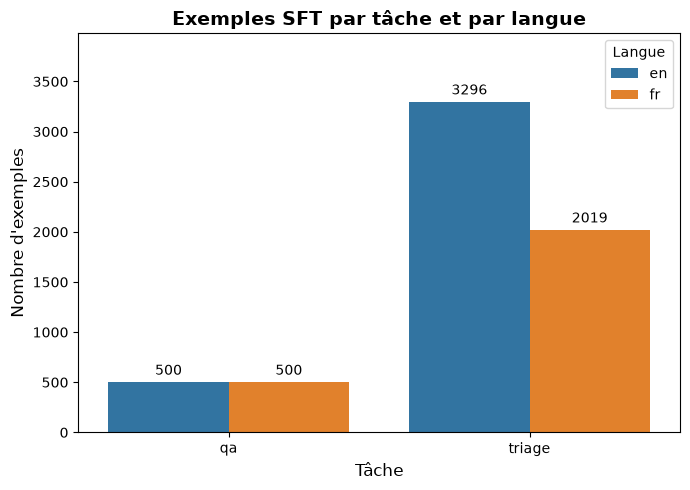

In [14]:
par_tache = composition.groupby(["tache", "langue"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(7, 5))
create_barplot(
    par_tache, ax, x="tache", y="n", hue="langue",
    title="Exemples SFT par tâche et par langue",
    xlabel="Tâche", ylabel="Nombre d'exemples",
    xrotation=0, fmt="{:.0f}", show_legend=True, legend_title="Langue",
)
plt.tight_layout()
save_figure(fig, "04_construction_sft/exemples_par_tache_et_langue")
plt.show()

Le total est provisoire : il montera quand toutes les vignettes anglaises seront annotées. Le nombre d'exemples de QA est lui aussi une valeur de départ.

## Contrôle de fuite

`find_leaks` cherche les clés de cas présentes dans plusieurs splits, cette fois sur les exemples générés et plus seulement sur le découpage.

Le contrôle a quelque chose à vérifier ici : un même cas MediQAl peut donner un exemple de triage et une ou plusieurs questions de QA. Ils doivent tous tomber dans le même split.

In [15]:
fuites = find_leaks(sft)
print("clés de cas présentes dans plusieurs splits :", len(fuites))

cles_triage = {e["cle_cas"] for e in triage}
communs = [e for e in qa if e["cle_cas"] in cles_triage]
print("exemples de QA dont le cas a aussi un exemple de triage :", len(communs))

clés de cas présentes dans plusieurs splits : 0
exemples de QA dont le cas a aussi un exemple de triage : 270


Le premier compteur doit être à zéro. Le second montre que le cas de figure existe vraiment : ces questions portent sur un patient qui a aussi son exemple de triage, et elles sont dans le même split que lui.

Le même contrôle sera relancé sur le SFT et le DPO ensemble, une fois les paires DPO construites.

## Vérification de `build_sft_dataset`

`build_sft_dataset` enchaîne toutes les étapes de ce notebook en un seul appel. C'est elle que le script d'export utilise. Je vérifie qu'elle donne les mêmes exemples, dans les mêmes splits.

In [16]:
verification = build_sft_dataset()
print("build_sft_dataset() :", len(verification), "exemples")
print("mêmes exemples et mêmes splits :", [(e["id"], e["split"]) for e in verification] == [(e["id"], e["split"]) for e in sft])

UltraMedical-Preference test: 100%|██████████| 777/777 [00:00<00:00, 3330.35it/s]


build_sft_dataset() : 6315 exemples
mêmes exemples et mêmes splits : True


## Synthèse

Le dataset SFT réunit deux tâches :

- **triage** : un exemple par cas annoté valide, avec la réponse en JSON écrite à partir de `SortieTriage` ;
- **QA** : environ 1 000 exemples tirés de MediQAl, FrenchMedMCQA et MedQuAD, moitié en français, moitié en anglais.

Nettoyage du QA : 49 doublons exacts retirés (48 dans MedQuAD, 1 dans FrenchMedMCQA), le « ? ? » final de MedQuAD corrigé, MediQAl et FrenchMedMCQA anonymisés. Les questions négatives de FrenchMedMCQA sont gardées, leurs propositions restent dans l'instruction.

Les splits viennent du découpage par cas du notebook 03 (80 % train, 10 % validation, 10 % test). Aucune clé de cas n'est dans deux splits.

La consigne n'est pas dans le dataset. Elle est ajoutée par `construire_prompt`, au même endroit pour l'entraînement, l'évaluation et l'API.

Ce qui reste provisoire : le nombre d'exemples de triage, tant que l'annotation n'est pas terminée, et le nombre d'exemples de QA.